# 02 — Exploratory Analysis & Leakage Hunting

**Project:** 30-Day Readmission Risk in Diabetic Inpatients
**Notebook 2 of 5**

---

Notebook 01 settled *who* is in the analysis and *what* is being predicted.
This notebook asks three questions of that cohort, in order:

1. **What does the data actually look like?** Distributions, missingness,
   plausibility.
2. **Is the missingness informative?** In clinical data, a blank is often a
   recorded decision rather than an absence.
3. **Is anything leaking?** Any feature that would not exist at the moment of
   discharge, or that encodes the outcome, has to be found now — not after a
   suspiciously good AUC.

Modelling still does not happen here. The point of this notebook is to know the
data well enough that nothing in notebook 03 is a surprise.

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = "../data"

### Load the cohort from notebook 01


In [2]:
df = pd.read_csv(f"{DATA_DIR}/processed/cohort.csv", low_memory=False)

print(f"Encounters: {len(df):,}")
print(f"Columns:    {df.shape[1]}")
print(f"Patients:   {df['patient_nbr'].nunique():,}")
print(f"Base rate:  {df['target'].mean():.1%}")

Encounters: 99,316
Columns:    39
Patients:   69,977
Base rate:  11.4%


### Sanity check against notebook 01


In [3]:
assert len(df) == 99316, f"Expected 99,316 encounters, got {len(df):,}"
assert df["target"].sum() == 11303, f"Expected 11,303 positives, got {df['target'].sum():,}"
assert "weight" not in df.columns, "weight should have been dropped in notebook 01"
assert "examide" not in df.columns, "examide should have been dropped in notebook 01"

print("Cohort matches notebook 01.")

Cohort matches notebook 01.


---
## 1. Numeric features: distributions



In [4]:
NUMERIC = ["time_in_hospital", "num_lab_procedures", "num_procedures",
           "num_medications", "number_outpatient", "number_emergency",
           "number_inpatient", "number_diagnoses"]

print(df[NUMERIC].describe().T.to_string())

                      count       mean        std  min   25%   50%   75%    max
time_in_hospital    99316.0   4.379335   2.968476  1.0   2.0   4.0   6.0   14.0
num_lab_procedures  99316.0  42.907286  19.609555  1.0  31.0  44.0  57.0  132.0
num_procedures      99316.0   1.334297   1.702804  0.0   0.0   1.0   2.0    6.0
num_medications     99316.0  15.979238   8.094892  1.0  10.0  15.0  20.0   81.0
number_outpatient   99316.0   0.369266   1.265236  0.0   0.0   0.0   0.0   42.0
number_emergency    99316.0   0.198367   0.937717  0.0   0.0   0.0   0.0   76.0
number_inpatient    99316.0   0.630724   1.259965  0.0   0.0   0.0   1.0   21.0
number_diagnoses    99316.0   7.401627   1.941069  1.0   6.0   8.0   9.0   16.0


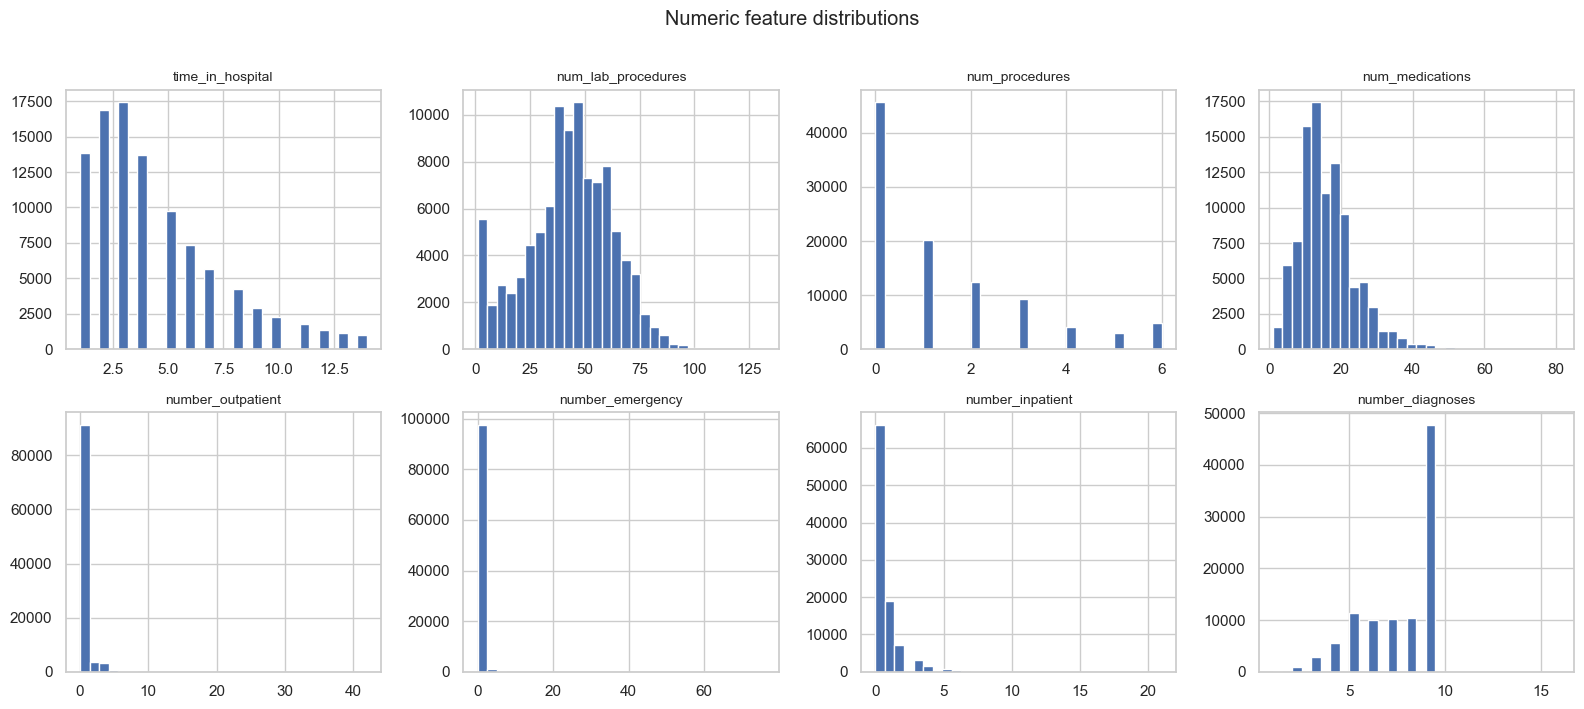

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.hist(df[col], bins=30, color="#4C72B0")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
plt.suptitle("Numeric feature distributions", y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# Does num_medications track length of stay and complexity of diagnosis?
print("num_medications by length of stay:")
print(df.groupby("time_in_hospital")["num_medications"]
        .agg(n="size", mean="mean", max="max").round(1).to_string())

print("\nCorrelations:")
print(df[["num_medications", "time_in_hospital",
          "number_diagnoses", "num_procedures"]].corr().round(2).to_string())

print("\nThe extreme cases (top 10 by medication count):")
print(df.nlargest(10, "num_medications")[
    ["num_medications", "time_in_hospital", "number_diagnoses",
     "num_lab_procedures", "diag_1", "age"]].to_string(index=False))

num_medications by length of stay:
                      n  mean  max
time_in_hospital                  
1                 13817  11.1   42
2                 16889  12.5   48
3                 17430  14.3   54
4                 13680  16.0   58
5                  9748  17.5   63
6                  7352  18.6   64
7                  5693  19.9   75
8                  4267  21.1   69
9                  2878  22.0   69
10                 2262  23.1   81
11                 1770  23.6   72
12                 1383  23.8   79
13                 1152  24.7   74
14                  995  25.5   72

Correlations:
                  num_medications  time_in_hospital  number_diagnoses  num_procedures
num_medications              1.00              0.46              0.26            0.38
time_in_hospital             0.46              1.00              0.22            0.19
number_diagnoses             0.26              0.22              1.00            0.07
num_procedures               0.38             

In [7]:
print(df.groupby("time_in_hospital")["num_medications"]
        .agg(n="size", mean="mean", p95=lambda s: s.quantile(0.95),
             max="max").round(1).to_string())

                      n  mean   p95  max
time_in_hospital                        
1                 13817  11.1  21.0   42
2                 16889  12.5  23.0   48
3                 17430  14.3  25.0   54
4                 13680  16.0  28.0   58
5                  9748  17.5  30.0   63
6                  7352  18.6  33.0   64
7                  5693  19.9  36.0   75
8                  4267  21.1  39.0   69
9                  2878  22.0  39.0   69
10                 2262  23.1  41.9   81
11                 1770  23.6  42.0   72
12                 1383  23.8  41.0   79
13                 1152  24.7  45.0   74
14                  995  25.5  46.0   72


In [8]:
# Metformin is contraindicated below eGFR 30, so patients on it should have
# renal function monitored. Does lab intensity differ?
print("num_lab_procedures by metformin status:")
print(df.groupby("metformin")["num_lab_procedures"]
        .agg(n="size", mean="mean").round(1).to_string())

print("\nControlling for length of stay (7-day stays only):")
d7 = df[df["time_in_hospital"] == 7]
print(d7.groupby("metformin")["num_lab_procedures"]
        .agg(n="size", mean="mean").round(1).to_string())

num_lab_procedures by metformin status:
               n  mean
metformin             
Down         573  45.2
No         79478  43.4
Steady     18202  40.7
Up          1063  46.5

Controlling for length of stay (7-day stays only):
              n  mean
metformin            
Down         47  53.1
No         4560  50.4
Steady      983  48.1
Up          103  52.1


## Do these distributions make clinical sense?

Four things I wanted to check before letting any of these become features.

### `time_in_hospital` — someone capped this before I got here

Stays run 1 to 14 days, and that wasn't my choice. The people who published this
dataset filtered out longer admissions before anyone downloaded it. So my audit
trail starts at 101,766 encounters that have already survived someone else's
filtering.

The patients that removes are exactly the ones I'd want to see. Severe sepsis. A
diabeix weeks of IV antibiotics. Complicated post-op courses.
Someone sitting on a ward waiting for a placement that never comes. Some of the
sickest diabetic inpatients in any hospital, and none of them are in this file.

I wouldn't have capped it. Length of stay is one of the more informative things
you get for free — a longer admission usually means sicker, and sicker usually
mo be readmittedikely to come back. Though it can cut the other way too: a long stay
might mean the problem actually got fixed, rather than the patient being sent
home half-treated. I can't tell which from this data, and that's exactly why the
variable shouldn't have been capped in the first place.

What bothers me most is how specific the loss is to this project. I'm building
something to help discharge planning, and the patients it will never see are the
ones with the hardest discharges.

### `num_medications` — I checked it rather than trusting it

Median 15, maximum 81. Fifteen is nothing unusual for an elderly diabetic who
also has h/or ESRDea81 and dodgy kidneys. Eighty-one needed a l2 variables: ook.

So I checked it against length of stay and against diagnosi length of hospitals. The mean climbs
steadily with stay, 11.1 at day one up to 25.5 at day fourteen, correlation 0.46
— which is how a running count is supposed to behave. Then I pulled the ten
highest-medication encounters. Every single one is diagnosis 410 or 414: acute
MI and coronary atherosclerosis. Stays of 7 to 14 days, 6 to 9 diagnoses, 52 to
85 lab procedures.

That's a picture I recognise. Diabetic patient comes in with an MI, spends a
fortnight in hospital, ends up on dual antiplatelets, anticoagulation, a statin,
a beta blocker, an ACE inhibitor, diuretics, insulin, something for pain, a PPI,
and a handful of PRNs. Eighty is a lot. It isn't impossible.

One toff hing about the maximum column that thr length of hospitalew me at first: it doesn't rise
cleanly with stay. Day 10 shows 81, day 14 shows 72. That looked wrong until I
noticed the sample sizes — 5,693 patients at seven days against 995 at fourteen.
The shorter stays get six times as many chances to contain one unusual person.
The 95th percentile, which actually uses the whole distribution, climbs neatly
from 21 to 46. Percentiles are the right tool here. The maximum is one patient.

Clinically I'd expect this variable to predict, and for honest reasons —
polypharmacy really does drive interactions, adverse events and people getting
their medications wrong once they're home.

### `number_diagnoses` — this is a form, not a patient

Range is 1 to 16, but 48% of encounters sit on exactly 9. Nearly half the cohort
landing on the same number isn't how illness distributes. Comorbidity spreads
out. It doesn't stack up on one value.

That's the shape of a form, not a patient. US claim submissions used to limit how
many diagnosis codes you could enter, and 9 was a common ceiling. So what I'm
looking at is where the coder ran out of boxes, not where the patient ran out of
problems.

Which means this variable is measuring documentation as much as it's measuring
illness. Someone with 16 codes isn't necessarily sicker than someone with 9 —
they might just have been admitted under a team that codes more carefully, or one
that had the time to finish the paperwork.

I'm keeping it, because how much gets coded probably does track real complexity
to some extent, and dropping a likely-predictive variable to avoid an awkward
caveat is the wrong trade. But if it shows up as important in the model, I'll
describe it as what it is — coding intensity, not comorbidity burden. Calling it
the second would be reading clinical meaning into a billing limit.

### `num_lab_procedures` — this one looks like a real ward

Median 44, IQR 31 to 57, fairly symmetric, tail running out to 132. And unlike
the utilisation counts, there's no pile-up at zero.

That's what ordering actually looks like. Patient comes in, gets a baseline panel
— FBC, U&Es, glucose, plus whatever the presentation demands. Then bloods get
repeated, daily for most people, more often if anything's off. Every abnormal
result buys you another test. The count just accumulates with each day on the
ward, which is precisely the rise I see against length of stay.

The missing zero spike is the part that reassures me most. An inpatient with no
bloods at all would be the real anomaly, and there isn't a group like that here.
If there were, I'd be looking for a data problem before a clinical explanation.

The long tail fits too. Those are the patients getting worked up hard —
unstable, undiagnosed, or going downhill — and I'd expect them to carry more
readmission risk for the same underlying reason.

### One thing I got wrong

Metformin is contraindicated below an eGFR of 30, so I assumed patients on it
would show more lab activity from renal monitoring. Held length of stay constant
at seven days and checked. The opposite: patients kept on metformin average 48.1
lab procedures, against 50.4 for those not on it, and 53.1 for those whose dose
was cut.

Then it clicked, backwards. Metformin gets held in renal impairment, in heart
failure, in acute illness. So a patient who stays on it through an admission is
by definition someone whose kidneys are fine and who isn't acutely unwell. That's
the *healthier* group. And my comparison group was never what I thought it was —
"No" lumps together people who were never on metformin with people whose
metformin was stopped, often because their renal function dropped.

So the lab count isn't tracking metformin monitoring at all. It's tracking how
sick someone is, and metformin status is just a marker of who's well enough to
stay on it. Confounding by indication, same as with the HbA1c result.

Worth carrying into notebook 03: if metformin comes out looking protective, the
reason isn't that metformin prevents readmission. It's that being well enough to
stay on metformin predicts doing well. Anyone reading a feature importance plot
without that in mind would draw a causal conclusion that's just wrong.

---
## 2. Categorical features: distributions


In [9]:
CATEGORICAL = ["race", "gender", "age", "admission_type_id",
               "discharge_disposition_id", "admission_source_id",
               "medical_specialty", "payer_code", "max_glu_serum",
               "A1Cresult", "change", "diabetesMed"]

for col in CATEGORICAL:
    n_levels = df[col].nunique(dropna=False)
    rare = (df[col].value_counts(dropna=False) < 100).sum()
    print(f"{col:<28} levels: {n_levels:>3}   levels with <100 rows: {rare:>3}")

race                         levels:   6   levels with <100 rows:   0
gender                       levels:   2   levels with <100 rows:   0
age                          levels:  10   levels with <100 rows:   0
admission_type_id            levels:   8   levels with <100 rows:   2
discharge_disposition_id     levels:  19   levels with <100 rows:   6
admission_source_id          levels:  17   levels with <100 rows:   7
medical_specialty            levels:  73   levels with <100 rows:  44
payer_code                   levels:  18   levels with <100 rows:   4
max_glu_serum                levels:   4   levels with <100 rows:   0
A1Cresult                    levels:   4   levels with <100 rows:   0
change                       levels:   2   levels with <100 rows:   0
diabetesMed                  levels:   2   levels with <100 rows:   0


In [10]:
for col in ["medical_specialty", "payer_code", "admission_source_id"]:
    vc = df[col].value_counts(dropna=False)
    top5_share = vc.head(5).sum() / len(df)
    print(f"\n{col}  ({df[col].nunique()} levels, top 5 cover {top5_share:.0%})")
    print(vc.head(8).to_string())


medical_specialty  (72 levels, top 5 cover 83%)
medical_specialty
NaN                       48596
InternalMedicine          14235
Emergency/Trauma           7417
Family/GeneralPractice     7252
Cardiology                 5278
Surgery-General            3059
Nephrology                 1539
Orthopedics                1391

payer_code  (17 levels, top 5 cover 87%)
payer_code
NaN    39390
MC     31325
HM      6190
SP      4941
BC      4601
MD      3471
CP      2463
UN      2411

admission_source_id  (17 levels, top 5 cover 98%)
admission_source_id
7     55836
1     29155
17     6570
4      3118
6      2239
2      1081
5       806
3       185


---
## 3. Missingness: how much, and where


In [11]:
miss = (df.isna().mean() * 100).round(1)
miss = miss[miss > 0].sort_values(ascending=False)

print("Columns with any missingness:")
print(miss.to_string())

Columns with any missingness:
max_glu_serum        94.8
A1Cresult            83.1
medical_specialty    48.9
payer_code           39.7
race                  2.2
diag_3                1.4
diag_2                0.4


### Does missingness cluster?


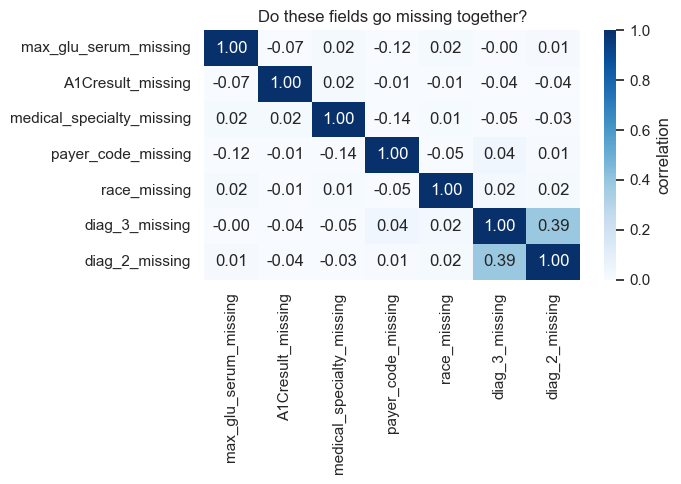

In [12]:
miss_cols = miss.index.tolist()
miss_flags = df[miss_cols].isna().astype(int)
miss_flags.columns = [c + "_missing" for c in miss_cols]

plt.figure(figsize=(7, 5))
sns.heatmap(miss_flags.corr(), annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, cbar_kws={"label": "correlation"})
plt.title("Do these fields go missing together?")
plt.tight_layout()
plt.show()

### The missingness doesn't cluster

Nothing here needs acting on. The only correlation worth mentioning is 0.39
between `diag_2` and `diag_3`, and that's structural rather than informative —
diagnosis slots fill in order, so a patient with fewer coded conditions is missing
both. Everything else sits below 0.15.

There's even a slightly negative relationship between `payer_code` and
`medical_specialty`, which doesn't fit a story about some records simply being
incomplete. If a particular facility or a particular era were dropping fields
wholesale, I'd expect these to go missing together. They don't.

So each column's missingness needs explaining on its own terms, and there's no
case for a combined "incomplete record" flag.

---
## 4. Is the missingness informative?


In [13]:
rows = []
for col in miss_cols:
    m = df[col].isna()
    rows.append({
        "column": col,
        "n_missing": m.sum(),
        "pct_missing": f"{m.mean():.1%}",
        "rate_when_missing": f"{df.loc[m, 'target'].mean():.1%}",
        "rate_when_present": f"{df.loc[~m, 'target'].mean():.1%}",
        "difference_pp": round((df.loc[m, "target"].mean()
                                - df.loc[~m, "target"].mean()) * 100, 1),
    })

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nCohort base rate: {df['target'].mean():.1%}")

           column  n_missing pct_missing rate_when_missing rate_when_present  difference_pp
    max_glu_serum      94164       94.8%             11.3%             12.8%           -1.4
        A1Cresult      82490       83.1%             11.7%              9.9%            1.8
medical_specialty      48596       48.9%             11.8%             11.0%            0.9
       payer_code      39390       39.7%             11.7%             11.2%            0.5
             race       2232        2.2%              8.4%             11.4%           -3.0
           diag_3       1419        1.4%              6.4%             11.5%           -5.0
           diag_2        356        0.4%              8.1%             11.4%           -3.2

Cohort base rate: 11.4%


In [14]:
# Does readmission rate differ by race, and who is in the missing group?

print(df.groupby("race", dropna=False)["target"]
        .agg(n="size", rate="mean")
        .assign(pct_of_cohort=lambda d: (d["n"]/len(df)*100).round(1),
                rate=lambda d: (d["rate"]*100).round(1))
        .sort_values("n", ascending=False).to_string())

# Is the missing-race group unusual in any other way?
print("\nAge profile — missing race vs recorded:")
print(pd.crosstab(df["race"].isna(), df["age"], normalize="index").round(2).to_string())

                     n  rate  pct_of_cohort
race                                       
Caucasian        74197  11.5           74.7
AfricanAmerican  18771  11.4           18.9
NaN               2232   8.4            2.2
Hispanic          2017  10.5            2.0
Other             1471   9.8            1.5
Asian              628  10.4            0.6

Age profile — missing race vs recorded:
age    [0-10)  [10-20)  [20-30)  [30-40)  [40-50)  [50-60)  [60-70)  [70-80)  [80-90)  [90-100)
race                                                                                           
False     0.0     0.01     0.02     0.04      0.1     0.17     0.22     0.25     0.17      0.03
True      0.0     0.00     0.02     0.03      0.1     0.16     0.22     0.26     0.17      0.03


In [15]:
# Are missing-race patients different in ways other than age?

for col in ["time_in_hospital", "number_inpatient", "number_diagnoses", "num_medications"]:
    print(f"{col:<22} missing: {df.loc[df['race'].isna(), col].mean():.2f}   "
          f"recorded: {df.loc[df['race'].notna(), col].mean():.2f}")

print("\nAdmission type:")
print(pd.crosstab(df["race"].isna(), df["admission_type_id"], normalize="index").round(2).to_string())

time_in_hospital       missing: 4.29   recorded: 4.38
number_inpatient       missing: 0.30   recorded: 0.64
number_diagnoses       missing: 6.66   recorded: 7.42
num_medications        missing: 15.77   recorded: 15.98

Admission type:
admission_type_id     1     2     3    4     5     6    7    8
race                                                          
False              0.53  0.18  0.19  0.0  0.05  0.05  0.0  0.0
True               0.48  0.31  0.16  0.0  0.03  0.03  0.0  0.0


### Payment source: is there a socioeconomic gradient?

In [16]:
# Does payment source predict readmission? Testing whether payer_code carries a
# socioeconomic gradient rather than just administrative noise.

print(df.groupby("payer_code", dropna=False)["target"]
        .agg(n="size", rate="mean")
        .assign(rate=lambda d: (d["rate"]*100).round(1))
        .query("n >= 100")
        .sort_values("rate", ascending=False)
        .to_string())

                n  rate
payer_code             
OG           1011  13.4
MC          31325  12.1
MD           3471  11.9
DM            545  11.7
NaN         39390  11.7
CM           1879  10.4
HM           6190  10.4
SP           4941  10.3
UN           2411   9.4
BC           4601   9.3
CH            142   9.2
CP           2463   8.6
PO            585   7.5
WC            135   3.7


In [17]:
# Is payer_code just a proxy for age? Check the age profile of each payment source

print("Most common age band per payer:")
print(df.groupby("payer_code")["age"].agg(lambda s: s.mode()[0]).to_string())

print("\nFull age distribution within each payer (row proportions):")
print(pd.crosstab(df["payer_code"], df["age"], normalize="index")
        .round(2).to_string())

Most common age band per payer:
payer_code
BC    [50-60)
CH    [60-70)
CM    [70-80)
CP    [50-60)
DM    [40-50)
FR    [60-70)
HM    [50-60)
MC    [70-80)
MD    [50-60)
MP    [50-60)
OG    [50-60)
OT    [50-60)
PO    [50-60)
SI    [40-50)
SP    [50-60)
UN    [50-60)
WC    [50-60)

Full age distribution within each payer (row proportions):
age         [0-10)  [10-20)  [20-30)  [30-40)  [40-50)  [50-60)  [60-70)  [70-80)  [80-90)  [90-100)
payer_code                                                                                          
BC             0.0     0.01     0.02     0.06     0.17     0.37     0.29     0.05     0.03      0.00
CH             0.0     0.01     0.01     0.02     0.09     0.25     0.37     0.15     0.09      0.00
CM             0.0     0.00     0.00     0.01     0.05     0.10     0.25     0.38     0.18      0.03
CP             0.0     0.01     0.02     0.05     0.18     0.30     0.29     0.10     0.05      0.01
DM             0.0     0.03     0.08     0.17     0.2

In [18]:
# Does the payer gradient survive once age is held constant?
# Same age band, different payment sources — if the spread flattens, it was age all along.

sub = df[df["age"] == "[70-80)"]
print(f"Patients aged 70-80: {len(sub):,}  (readmission rate {sub['target'].mean():.1%})\n")

print(sub.groupby("payer_code")["target"]
        .agg(n="size", rate="mean")
        .assign(rate=lambda d: (d["rate"] * 100).round(1))
        .query("n >= 100")
        .sort_values("rate", ascending=False)
        .to_string())

Patients aged 70-80: 25,324  (readmission rate 12.0%)

                n  rate
payer_code             
MD            288  14.2
HM           1030  13.0
MC          11229  11.8
SP            837  10.6
CP            240  10.0
UN            420   9.0
BC            231   8.7
CM            706   8.5


## Is the missingness informative?

Seven columns have gaps in them. They turned out to fall into three groups, and
only one of those is what I was actually looking for.

### Two that don't matter

`medical_specialty` is 48.9% missing and `payer_code` is 39.7%. Patients missing
these fields come back at 11.8% and 11.7%. The cohort as a whole comes back at
11.4%. Those are the same number for practical purposes, which means a blank in
either field tells me nothing about the patient's risk.

They still get an "unknown" category, because that's more honest than imputing
something. But it's a placeholder, not a finding.

For what it's worth, I'd guess a blank `medical_specialty` usually means nobody
recorded the admitting service rather than that there wasn't one — someone
admitted through the emergency department under a general rota, or a field that
just never got filled. A blank `payer_code` in a US record probably means the
payment source wasn't settled when the record was coded: self-pay, uninsured, a
claim still in limbo, someone who absconded before the bill was resolved.

Worth being clear that this only says the *blank* carries no signal. Whether the
recorded values do is a different question, and I test it further down.

### The one I was actually testing

`A1Cresult`, 83.1% missing.

In notebook 01 I argued that a blank here means the test was never ordered, and
that a diabetic inpatient whose HbA1c nobody checked is probably an admission
where the diabetes wasn't really the focus. The numbers back that up: patients
with no HbA1c come back at 11.7%, those who had one at 9.9%.

It went the way I predicted. But I want to be honest about the size of it — 1.8
percentage points on a base of 11.4%, so about a 16% relative difference. Real,
given nearly 100,000 encounters. Not dramatic. So this is *consistent with* the
discharge-quality reading rather than proof of it, and I've gone back and softened
how I wrote it in notebook 01.

And I can't say which way the causation runs. Not ordering an HbA1c doesn't cause
someone to be readmitted. Both are probably downstream of an admission where
nobody was paying close attention to the diabetes.

`max_glu_serum` is stranger — it runs the other way. Patients who *had* a serum
glucose come back more, 12.8% against 11.3%.

That looked contradictory until I thought about what each test is for. You order a
random glucose because someone is acutely unwell in front of you. You order an
HbA1c because you're thinking about their long-term control. So one marks acuity
and the other marks attention. Opposite directions, and both make sense.

### The three I didn't see coming

These have the biggest differences, and they aren't really about missingness at
all.

| Column | Missing | Present | Difference |
|---|---|---|---|
| `diag_3` | 6.4% | 11.5% | −5.0pp |
| `diag_2` | 8.1% | 11.4% | −3.2pp |
| `race` | 8.4% | 11.4% | −3.0pp |

A missing third diagnosis gives a readmission rate of 6.4% against a cohort rate
of 11.4%. Nearly half.

That's not a data problem. Diagnosis codes fill in order, so a blank `diag_3`
means the patient didn't have a third condition to code. The field isn't recording
missing information — it's recording that there was less wrong with them. These
patients are healthier, and healthier patients come back less.

Which is the same thing `number_diagnoses` was telling me, approached from a
different angle. It also explains that 0.39 correlation between `diag_2` and
`diag_3` missingness in the clustering check — structural, not some shared cause.

`race` at −3.0pp looked like it needed a mechanism, so I went looking for one. The
missing-race group turns out to have half the prior admission history of the rest
(0.30 previous inpatient stays against 0.64), fewer coded diagnoses (6.66 against
7.42), and a noticeably different admission profile — 31% urgent admissions
against 18% for patients whose race was recorded.

So these are patients arriving through a more hurried route, who are less known to
the hospital, with less comorbidity. Their age profile is identical to everyone
else's, which is what sent me looking further. A blank race field is an
administrative fingerprint of that kind of arrival, not a fact about the patient's
race — and the lower readmission rate follows from who they are, not from what
wasn't recorded.

Worth noting that race itself barely predicts anything here. Caucasian 11.5%,
African American 11.4%, and those two groups are 94% of the cohort. The signal was
never in the variable. It was in the circumstances of the encounter that left it
blank.

---

## Payment source: is there a socioeconomic gradient?

The section above asked whether a *missing* `payer_code` predicts readmission. It
doesn't. But that's the wrong question for what I actually want to know.

My reason for keeping this variable was never administrative. It's that payment
source is the closest thing this dataset has to a socioeconomic measure. A patient
on private insurance, a patient on public insurance, and a patient paying cash are
in three different financial positions, and I'd expect that to show up in whether
they come back.

So I looked at the recorded values.

| Payer | n | Readmission rate |
|---|---|---|
| OG (government, other) | 1,011 | 13.4% |
| MC (Medicare) | 31,325 | 12.1% |
| MD (Medicaid) | 3,471 | 11.9% |
| (blank) | 39,390 | 11.7% |
| HM (HMO) | 6,190 | 10.4% |
| SP (self-pay) | 4,941 | 10.3% |
| UN | 2,411 | 9.4% |
| BC (Blue Cross) | 4,601 | 9.3% |
| CP (commercial) | 2,463 | 8.6% |
| WC (workers' comp) | 135 | 3.7% |

Public insurance at the top, commercial at the bottom. That looks like the
gradient I expected.

Except self-pay sits at 10.3%, *below* the cohort average. If this were purely
about affording care, uninsured patients should be near the top. They aren't.

### It's mostly age

Medicare covers people over 65 and the disabled — the frailest, most comorbid
group in any hospital. Commercial insurance covers people who are employed, which
means well enough to work.

The age breakdown confirms it. Medicare patients are 69% aged 70 or over. Blue
Cross is 8%. Commercial is 16%. Workers' compensation is 4% — those are people
injured at work, so by definition healthy enough to have been working.

So most of that raw ordering is a story about who is old, not who is poor.

### But it isn't only age

Holding age constant at 70-80 — 25,324 patients, readmission rate 12.0%:

| Payer | n | Rate |
|---|---|---|
| MD (Medicaid) | 288 | 14.2% |
| HM (HMO) | 1,030 | 13.0% |
| MC (Medicare) | 11,229 | 11.8% |
| SP (self-pay) | 837 | 10.6% |
| CP (commercial) | 240 | 10.0% |
| BC (Blue Cross) | 231 | 8.7% |
| CM | 706 | 8.5% |

The spread is 5.7 percentage points *within a single age band* — wider than the
5.1 points across the whole cohort. Age wasn't creating the gradient. It was
hiding it.

Medicaid is the finding. A 70-to-80 year old on Medicaid comes back at 14.2%. The
same age on Blue Cross comes back at 8.7%. Nearly double. At that age Medicaid
means dual eligibility — old enough for Medicare, poor enough to qualify for
Medicaid as well — so it's a fairly direct marker of poverty.

Two honest caveats. The group sizes are small: 288 Medicaid patients, 231 on Blue
Cross. A confidence interval around 14.2% from 288 patients runs roughly 10% to
18%, and around 8.7% from 231 runs roughly 5% to 13%. Those overlap. The pattern
across seven payers is more convincing than any single pairwise comparison, and I
wouldn't quote the individual numbers as precise.

And self-pay still sits below average at 10.6%, which doesn't fit a simple poverty
story. I can't explain that one.

### What this means for the model

There is a socioeconomic signal here, and it survives controlling for age. So
`payer_code` stays in.

But it creates a problem I need to carry into notebook 04. The model will score
poor elderly patients as higher risk — correctly, because they are — and the
intervention it triggers won't touch the reason. Medication reconciliation, a
diabetes educator session, an appointment booked before discharge, a call at 72
hours: none of that helps someone who is coming back because they can't afford
their insulin.

That's uncomfortably close to the hospice problem from notebook 01. Right
prediction, wrong intervention available. The difference is that here I don't
think the answer is exclusion — these patients genuinely need more support, and a
model that flags them and says why is more useful than one that stays silent.

What it means is that the tool tells a discharge team *who*. Somebody still has to
ask *why*, because the answer decides whether the standard bundle is the right
response or a useless one.

### The pattern across all of this

Three times in this notebook a variable has looked like it meant one thing and
turned out to mean another.

Metformin looked like it should drive renal monitoring, and instead marked who was
well enough to stay on it. `payer_code` looked like a socioeconomic gradient, and
was mostly age — until age was controlled, at which point a real socioeconomic
signal appeared underneath. Missing `race` looked like it needed a demographic
explanation, and turned out to be a fingerprint of hurried admissions in patients
new to the hospital.

Every one of them was proxying for either acuity or prior utilisation. That's
worth carrying into notebook 03 as a standing caution: in this dataset, most
apparent effects are severity wearing a different label, and a feature importance
plot read at face value will produce confident nonsense.

### What I'm doing about it

Nothing gets imputed. Everything becomes an explicit category — but for three
different reasons.

`A1Cresult` and `max_glu_serum`, because the blank is a clinical decision someone
made. The diagnosis fields, because the blank marks a less complicated patient.
`medical_specialty` and `payer_code`, because "unknown" is just the honest label
for a gap that doesn't tell me anything — even though the recorded values of
`payer_code` clearly do.

One caution over all of it: every number above is an association. None of it tells
me which direction the causation runs.ap that doesn't tell me anything — even though the recorded values of
`payer_code` clearly do.

One caution over all of it: every number above is an association. None of it tells
me which direction the causation runs. caution over all of it: every number above is an association. None of it tells
me which direction the causation runs, and for `race` I'd rather say it's noise
than pretend I have a mechanism.

---
## 5. Numeric features against the outcome


In [19]:
summary = df.groupby("target")[NUMERIC].mean().T
summary.columns = ["not_readmitted", "readmitted"]
summary["difference"] = summary["readmitted"] - summary["not_readmitted"]
summary["ratio"] = (summary["readmitted"] / summary["not_readmitted"]).round(2)

print(summary.round(2).to_string())

                    not_readmitted  readmitted  difference  ratio
time_in_hospital              4.33        4.77        0.44   1.10
num_lab_procedures           42.74       44.23        1.49   1.03
num_procedures                1.34        1.28       -0.06   0.96
num_medications              15.86       16.91        1.05   1.07
number_outpatient             0.36        0.44        0.08   1.21
number_emergency              0.18        0.36        0.18   2.01
number_inpatient              0.55        1.22        0.67   2.20
number_diagnoses              7.36        7.69        0.33   1.04


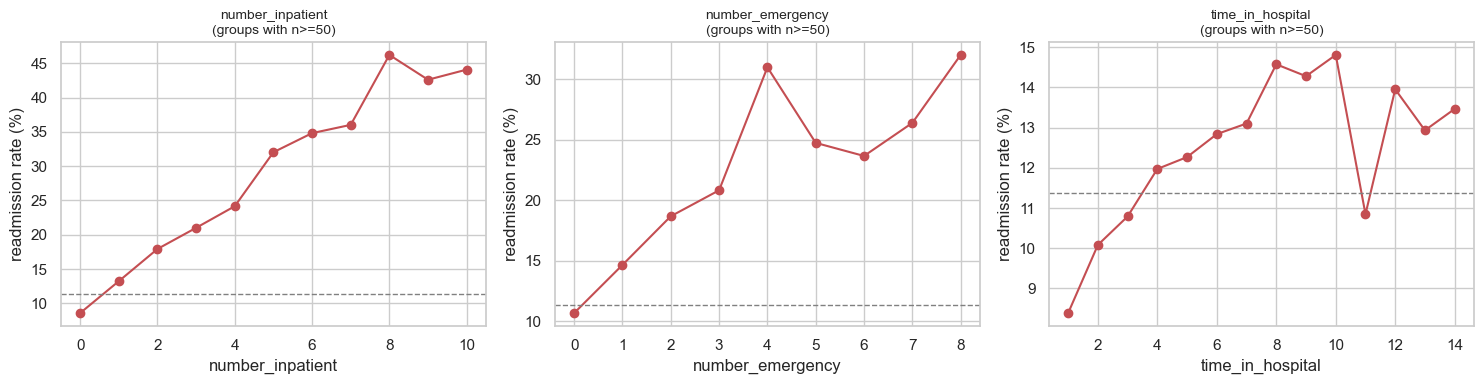

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["number_inpatient", "number_emergency", "time_in_hospital"]):
    g = df.groupby(col)["target"].agg(["size", "mean"])
    g = g[g["size"] >= 50]                      # suppress unstable estimates
    ax.plot(g.index, g["mean"] * 100, marker="o", color="#C44E52")
    ax.axhline(df["target"].mean() * 100, ls="--", c="grey", lw=1)
    ax.set_xlabel(col)
    ax.set_ylabel("readmission rate (%)")
    ax.set_title(f"{col}\n(groups with n>=50)", fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Categorical features against the outcome


In [21]:
def rate_table(col, min_n=100):
    g = df.groupby(col, dropna=False)["target"].agg(n="size", rate="mean")
    g = g[g["n"] >= min_n].sort_values("rate", ascending=False)
    g["rate"] = (g["rate"] * 100).round(1)
    return g

for col in ["age", "race", "gender", "A1Cresult", "change", "diabetesMed"]:
    print(f"\n--- {col} (base rate {df['target'].mean():.1%}) ---")
    print(rate_table(col).to_string())


--- age (base rate 11.4%) ---
              n  rate
age                  
[20-30)    1649  14.3
[80-90)   16430  12.6
[70-80)   25324  12.0
[90-100)   2588  11.9
[60-70)   22047  11.3
[30-40)    3764  11.3
[40-50)    9605  10.7
[50-60)   17060   9.8
[10-20)     689   5.8
[0-10)      160   1.9

--- race (base rate 11.4%) ---
                     n  rate
race                        
Caucasian        74197  11.5
AfricanAmerican  18771  11.4
Hispanic          2017  10.5
Asian              628  10.4
Other             1471   9.8
NaN               2232   8.4

--- gender (base rate 11.4%) ---
            n  rate
gender             
Female  53444  11.5
Male    45872  11.3

--- A1Cresult (base rate 11.4%) ---
               n  rate
A1Cresult             
NaN        82490  11.7
>7          3772  10.1
>8          8134   9.9
Norm        4920   9.8

--- change (base rate 11.4%) ---
            n  rate
change             
Ch      46106  12.0
No      53210  10.8

--- diabetesMed (base rate 11.4%) ---

### Age is worth its own look

Notebook 01 committed to reporting the under-20 subgroup separately. This is the
first sight of how the outcome varies across the full age range.

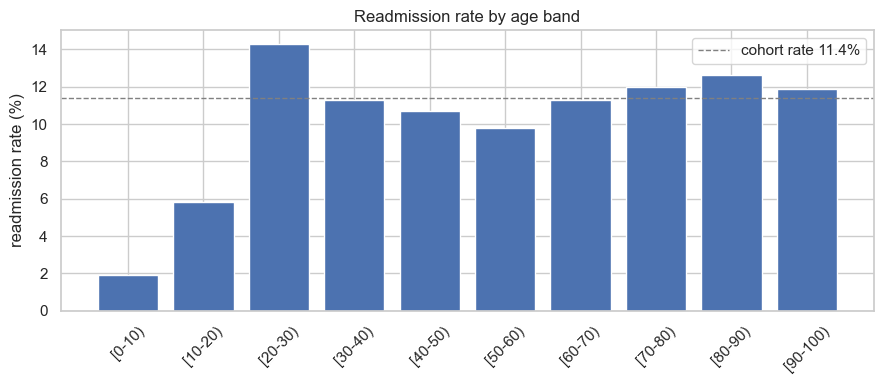

              n  rate_pct
age                      
[0-10)      160       1.9
[10-20)     689       5.8
[20-30)    1649      14.3
[30-40)    3764      11.3
[40-50)    9605      10.7
[50-60)   17060       9.8
[60-70)   22047      11.3
[70-80)   25324      12.0
[80-90)   16430      12.6
[90-100)   2588      11.9


In [22]:
g = df.groupby("age")["target"].agg(n="size", rate="mean").sort_index()
g["rate_pct"] = (g["rate"] * 100).round(1)

plt.figure(figsize=(9, 4))
plt.bar(g.index, g["rate_pct"], color="#4C72B0")
plt.axhline(df["target"].mean() * 100, ls="--", c="grey", lw=1,
            label=f"cohort rate {df['target'].mean():.1%}")
plt.ylabel("readmission rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.title("Readmission rate by age band")
plt.tight_layout()
plt.show()

print(g[["n", "rate_pct"]].to_string())

### What the categorical rates show

Three things stand out here.

**A1C: the flag matters, the result doesn't.** Norm 9.8%, above 7 at 10.1%, above
8 at 9.9%. Those are the same number. Poor glycaemic control, as measured by the
actual HbA1c value, doesn't predict readmission at all in this cohort. But not
having the test done sits at 11.7% — higher than any of the recorded values.

That's a stronger version of the argument I made in notebook 01, and it changes
what I'd keep. The measurement decision carries the signal. The result carries
almost none. I could drop the result categories entirely and lose very little.

**`change` and `diabetesMed` are acuity again.** Medication changed 12.0% against
unchanged 10.8%. On diabetes medication 11.8% against not on it 9.9%.

Same story as metformin. Patients whose regimen needed adjusting were the ones
unwell enough to need adjusting, and patients on diabetes medication at all are
the ones whose diabetes was active enough to treat. Neither is telling me anything
about the drugs.

**Race and gender are genuinely null.** Female 11.5% against male 11.3%.
Caucasian 11.5% against African American 11.4%, and those two groups are 94% of
the cohort.

That's worth stating plainly rather than passing over, because it sets up the
fairness work in notebook 04. If the model ends up performing differently across
these groups, the difference cannot be coming from the groups having different
underlying risk. It would have to be coming from other features that correlate
with group membership — which is a much more specific thing to go looking for than
"check for bias".

The age curve I've dealt with separately in section 10, where the confidence
intervals make it easier to say what's real.

---
## 7. Diagnosis codes


In [23]:
# First pass at grouping the ICD-9 codes into clinical chapters, following the
# scheme used in the original study on this dataset. This version is superseded
# further down, after I looked at what the "Other" bucket actually contained and
# found it was hiding blocks with very different readmission rates.

def icd9_group(code):
    """Map an ICD-9 code to a broad clinical category."""
    if pd.isna(code):
        return "Missing"
    s = str(code)

    # V and E codes: supplementary classifications
    if s.startswith("V"):
        return "Other"
    if s.startswith("E"):
        return "Injury"

    try:
        n = float(s)
    except ValueError:
        return "Other"

    if 250 <= n < 251:                       return "Diabetes"
    if 390 <= n <= 459 or int(n) == 785:     return "Circulatory"
    if 460 <= n <= 519 or int(n) == 786:     return "Respiratory"
    if 520 <= n <= 579 or int(n) == 787:     return "Digestive"
    if 580 <= n <= 629 or int(n) == 788:     return "Genitourinary"
    if 800 <= n <= 999:                      return "Injury"
    if 710 <= n <= 739:                      return "Musculoskeletal"
    if 140 <= n <= 239:                      return "Neoplasms"
    return "Other"


for c in ["diag_1", "diag_2", "diag_3"]:
    df[c + "_group"] = df[c].apply(icd9_group)

print("Primary diagnosis (diag_1) by clinical group:\n")
print(rate_table("diag_1_group", min_n=50).to_string())

Primary diagnosis (diag_1) by clinical group:

                     n  rate
diag_1_group                
Diabetes          8660  13.1
Injury            6850  12.4
Circulatory      29675  11.7
Other            17783  11.7
Genitourinary     5002  11.0
Neoplasms         3130  10.9
Digestive         9331  10.8
Respiratory      13931  10.0
Musculoskeletal   4934   9.5


In [24]:
share = df["diag_1_group"].value_counts(normalize=True).mul(100).round(1)
print("Share of encounters by primary diagnosis group (%):")
print(share.to_string())

Share of encounters by primary diagnosis group (%):
diag_1_group
Circulatory        29.9
Other              17.9
Respiratory        14.0
Digestive           9.4
Diabetes            8.7
Injury              6.9
Genitourinary       5.0
Musculoskeletal     5.0
Neoplasms           3.2
Missing             0.0


In [25]:
# What is actually in the "Other" group? 17.9% of encounters is too large to leave unexamined.

other = df[df["diag_1_group"] == "Other"]
print(f"Other: {len(other):,} encounters ({len(other)/len(df):.1%})\n")
print("Top 20 codes:")
print(other["diag_1"].value_counts().head(20).to_string())

Other: 17,783 encounters (17.9%)

Top 20 codes:
diag_1
682    2029
780    2004
276    1839
38     1496
V57    1199
296     894
789     560
8       504
295     446
278     378
285     361
280     317
648     285
707     251
V58     226
331     189
784     151
386     145
790     142
348     135


In [26]:
# Do the coherent blocks inside "Other" have distinct readmission rates?

def other_block(code):
    s = str(code)
    if s.startswith(("38", "682", "8", "707")) and not s.startswith("780"):
        return "Infection"
    if s.startswith(("295", "296", "29")):
        return "Mental health"
    if s.startswith("276"):
        return "Fluid/electrolyte"
    if s.startswith("V"):
        return "Aftercare/V-code"
    if s.startswith("780"):
        return "Symptoms, ill-defined"
    return "Other residual"

o = df[df["diag_1_group"] == "Other"].copy()
o["block"] = o["diag_1"].apply(other_block)

print(o.groupby("block")["target"]
       .agg(n="size", rate="mean")
       .assign(rate=lambda d: (d["rate"]*100).round(1))
       .sort_values("rate", ascending=False).to_string())

                          n  rate
block                            
Aftercare/V-code       1631  16.2
Fluid/electrolyte      1839  13.9
Mental health          1867  12.4
Infection              4486  11.0
Other residual         5956  10.7
Symptoms, ill-defined  2004   9.5


In [27]:
# Refine the diagnosis grouping: pull four coherent blocks out of "Other".
# Aftercare, fluid/electrolyte, mental health and ill-defined symptoms each sit
# meaningfully away from the 11.4% base rate. Infection and the residual do not,
# so they stay grouped.

def icd9_group(code):
    """Map an ICD-9 code to a clinical category."""
    if pd.isna(code):
        return "Missing"
    s = str(code)

    # V and E codes: supplementary classifications
    if s.startswith("V"):
        return "Aftercare"           # V57 rehab, V58 other aftercare
    if s.startswith("E"):
        return "Injury"

    try:
        n = float(s)
    except ValueError:
        return "Other"

    if 250 <= n < 251:                       return "Diabetes"
    if 390 <= n <= 459 or int(n) == 785:     return "Circulatory"
    if 460 <= n <= 519 or int(n) == 786:     return "Respiratory"
    if 520 <= n <= 579 or int(n) == 787:     return "Digestive"
    if 580 <= n <= 629 or int(n) == 788:     return "Genitourinary"
    if 800 <= n <= 999:                      return "Injury"
    if 710 <= n <= 739:                      return "Musculoskeletal"
    if 140 <= n <= 239:                      return "Neoplasms"

    # Blocks pulled out of the former "Other" bucket
    if int(n) == 276:                        return "Fluid/electrolyte"
    if 290 <= n <= 319:                      return "Mental health"
    if int(n) == 780:                        return "Symptoms, ill-defined"

    return "Other"


for c in ["diag_1", "diag_2", "diag_3"]:
    df[c + "_group"] = df[c].apply(icd9_group)

print("Primary diagnosis groups, by readmission rate:\n")
print(df.groupby("diag_1_group")["target"]
        .agg(n="size", rate="mean")
        .assign(share=lambda d: (d["n"]/len(df)*100).round(1),
                rate=lambda d: (d["rate"]*100).round(1))
        .sort_values("rate", ascending=False).to_string())
print(f"\nCohort base rate: {df['target'].mean():.1%}")

Primary diagnosis groups, by readmission rate:

                           n  rate  share
diag_1_group                             
Missing                   20  25.0    0.0
Aftercare               1631  16.2    1.6
Fluid/electrolyte       1839  13.9    1.9
Diabetes                8660  13.1    8.7
Injury                  6850  12.4    6.9
Mental health           2251  12.1    2.3
Circulatory            29675  11.7   29.9
Genitourinary           5002  11.0    5.0
Neoplasms               3130  10.9    3.2
Digestive               9331  10.8    9.4
Other                  10058  10.8   10.1
Respiratory            13931  10.0   14.0
Musculoskeletal         4934   9.5    5.0
Symptoms, ill-defined   2004   9.5    2.0

Cohort base rate: 11.4%


In [28]:
# What are the 20 encounters with no primary diagnosis?

m = df[df["diag_1_group"] == "Missing"]
print(m[["age", "time_in_hospital", "number_diagnoses",
         "diag_2", "diag_3", "admission_type_id", "target"]].to_string(index=False))

    age  time_in_hospital  number_diagnoses diag_2 diag_3  admission_type_id  target
[60-70)                 4                 4    780    997                  6       0
[80-90)                 3                 7    595  250.6                  3       0
[60-70)                 3                 5 250.82    401                  3       0
[60-70)                 5                 8    276    594                  3       0
[70-80)                 1                 7 250.01    428                  3       0
[50-60)                 1                 4    496    788                  3       0
[20-30)                 6                 6    276 250.01                  1       0
[60-70)                 4                 8    112    585                  1       0
[50-60)                 4                 9    998    427                  1       0
[40-50)                 4                 9    780    295                  1       1
[80-90)                 4                 8    707    427        

In [29]:
# 20 encounters have no primary diagnosis recorded, though diag_2 and diag_3 are
# populated normally. Too few to support a category; folded into "Other".

df["diag_1_group"] = df["diag_1_group"].replace("Missing", "Other")

print(df["diag_1_group"].value_counts().to_string())

diag_1_group
Circulatory              29675
Respiratory              13931
Other                    10078
Digestive                 9331
Diabetes                  8660
Injury                    6850
Genitourinary             5002
Musculoskeletal           4934
Neoplasms                 3130
Mental health             2251
Symptoms, ill-defined     2004
Fluid/electrolyte         1839
Aftercare                 1631


In [30]:
# Does splitting the Diabetes group by type and complication change anything?
# In ICD-9 250.xy: y = 1 or 3 means type 1, y = 0 or 2 means type 2.
# x = 1 is ketoacidosis, 2 hyperosmolar, 3 other coma, 0 no complication.

dm = df[df["diag_1_group"] == "Diabetes"].copy()

def dm_detail(code):
    s = str(code)
    if len(s) < 6:
        return "250 unspecified"
    fourth, fifth = s[4], s[5]
    typ = "type 1" if fifth in "13" else "type 2"
    comp = {"0": "no complication", "1": "ketoacidosis",
            "2": "hyperosmolar", "3": "other coma"}.get(fourth, "other complication")
    return f"{typ}, {comp}"

dm["dm_detail"] = dm["diag_1"].apply(dm_detail)

print(dm.groupby("dm_detail")["target"]
        .agg(n="size", rate="mean")
        .assign(rate=lambda d: (d["rate"]*100).round(1))
        .query("n >= 50")
        .sort_values("rate", ascending=False).to_string())
print(f"\nDiabetes group overall: {dm['target'].mean():.1%}   Cohort: {df['target'].mean():.1%}")

                               n  rate
dm_detail                             
type 2, other complication   555  16.6
type 1, other complication   419  15.5
250 unspecified             4633  14.0
type 1, ketoacidosis        1472  13.7
type 2, ketoacidosis         415   9.2
type 2, no complication      673   7.9
type 2, hyperosmolar         147   6.8
type 1, no complication      260   6.2

Diabetes group overall: 13.1%   Cohort: 11.4%


In [31]:
# Split the Diabetes group by complication status, not by type.
# The earlier breakdown showed complications drive the difference (complicated
# ~16%, uncomplicated ~7%) while type 1 vs type 2 barely separates within each.
# ICD-9 250.xy: x is the complication digit, y the type digit.
# x = 0 -> no complication; x = 1,2,3 -> acute metabolic; x = 4-9 -> chronic complications.
# Codes without a fourth digit cannot be classified and stay separate.

def diabetes_detail(code):
    s = str(code)
    if len(s) < 6:
        return "Diabetes, unspecified"
    comp = s[4]
    if comp == "0":
        return "Diabetes, uncomplicated"
    return "Diabetes, complicated"


mask = df["diag_1_group"] == "Diabetes"
df.loc[mask, "diag_1_group"] = df.loc[mask, "diag_1"].apply(diabetes_detail)

print(df.groupby("diag_1_group")["target"]
        .agg(n="size", rate="mean")
        .assign(share=lambda d: (d["n"] / len(df) * 100).round(1),
                rate=lambda d: (d["rate"] * 100).round(1))
        .sort_values("rate", ascending=False).to_string())
print(f"\nCohort base rate: {df['target'].mean():.1%}")

                             n  rate  share
diag_1_group                               
Aftercare                 1631  16.2    1.6
Diabetes, unspecified     4633  14.0    4.7
Fluid/electrolyte         1839  13.9    1.9
Diabetes, complicated     3094  13.5    3.1
Injury                    6850  12.4    6.9
Mental health             2251  12.1    2.3
Circulatory              29675  11.7   29.9
Genitourinary             5002  11.0    5.0
Neoplasms                 3130  10.9    3.2
Other                    10078  10.9   10.1
Digestive                 9331  10.8    9.4
Respiratory              13931  10.0   14.0
Musculoskeletal           4934   9.5    5.0
Symptoms, ill-defined     2004   9.5    2.0
Diabetes, uncomplicated    933   7.4    0.9

Cohort base rate: 11.4%


## The diagnosis grouping

There are over 700 different ICD-9 codes in `diag_1`. Far too many to put into a
model directly, so they have to be grouped. The question I care about is whether
the grouping is honest — whether it hides things a clinician would want to see.

### Does the ordering make sense?

Mostly, yes. When I looked at the chapter-level rates they read like a real ward.

Diabetes as the primary reason for admission came out highest of the original
groups, which is what I'd expect. Someone admitted *for* their diabetes has a
problem that keeps happening. Someone admitted with a fractured hip who happens to
be diabetic doesn't. Musculoskeletal was lowest, and that fits too — you fix the
joint and the thing is fixed. Circulatory was nearly 30% of all encounters, which
is the diabetic comorbidity burden turning up exactly where you'd expect to find
it.

### But "Other" was too big to just leave sitting there

It was 17.9% of encounters, the second-biggest group, and I had no idea what was
inside it. So I looked.

Turns out it wasn't a junk drawer. There were proper clinical blocks in there, and
when I pulled their rates apart they looked nothing like each other:

| Block | n | Rate |
|---|---|---|
| Aftercare (V-codes) | 1,631 | 16.2% |
| Fluid/electrolyte | 1,839 | 13.9% |
| Mental health | 1,867 | 12.4% |
| Infection | 4,486 | 11.0% |
| Other residual | 5,956 | 10.7% |
| Symptoms, ill-defined | 2,004 | 9.5% |

Aftercare came out on top at 16.2% — higher than any other primary diagnosis in
the whole dataset. That surprised me until I thought about who actually gets
admitted for aftercare. They're not there for anything acute. They're there
because they're recovering from something and can't cope on their own. That's
frailty, and frailty predicts coming back better than most acute diagnoses do. It
also matches what I found looking at discharge destinations, where rehab
facilities had the highest readmission rate of anywhere. Same patients, seen from
the other end of the admission.

Fluid and electrolyte disorders at 13.9% shouldn't really have surprised me
either. Code 276 in a diabetic usually means dehydration or an electrolyte mess —
often renal, often recurrent, sometimes a near-DKA that didn't quite get coded as
one.

Infection at 11.0% is the one I got wrong. I assumed diabetic foot and sepsis
would be near the top. They sit at the cohort average. One thing that might
explain it: septicaemia kills people, and those patients left this cohort by dying
rather than by being readmitted. Same competing-risk problem I noticed with the
long-term care hospitals.

So I pulled out four of them — Aftercare, Fluid/electrolyte, Mental health, and
Symptoms. I left Infection and the residual where they were. Both are within half
a point of the base rate, so giving them their own categories would just add
columns that say nothing and water down the ones that actually matter.

### Is chapter-level grouping too coarse?

For most of these, no. But I wanted to test it on the group I care most about, and
for diabetes the answer was obviously yes.

| | n | Rate |
|---|---|---|
| Type 2, other complication | 555 | 16.6% |
| Type 1, other complication | 419 | 15.5% |
| Type 1, ketoacidosis | 1,472 | 13.7% |
| Type 2, ketoacidosis | 415 | 9.2% |
| Type 2, no complication | 673 | 7.9% |
| Type 1, no complication | 260 | 6.2% |

Ten percentage points from top to bottom, all of it flattened into a single 13.1%
when the group was left whole.

What's driving it is complications, not type. Complicated diabetes runs at roughly
double uncomplicated, and within each pair type 1 and type 2 sit close together.
"Other complication" is the 250.4 to 250.9 range — nephropathy, neuropathy, eye
disease, peripheral vascular disease. End-organ damage that's already happened,
and it predicts coming back.

The one place type does matter is DKA. Type 1 at 13.7%, type 2 at 9.2%. Same acute
presentation, very different outcome, and that reads true to me. Type 1 DKA is
usually insulin being missed or self-management falling apart, and whatever caused
that is still there when the patient goes home. Type 2 DKA is rarer and usually
set off by something acute — an infection, an illness — which gets treated and
doesn't repeat in the same way.

So I split diabetes by whether there are complications, rather than by type. Three
levels instead of eight, it keeps nearly all of the separation, and it means I'm
not fitting a category on 147 patients.

The unspecified block is the awkward one — 4,633 encounters coded without a fourth
digit, so I genuinely can't tell which side they belong on. It sits at 14.0%,
nearer complicated than uncomplicated. Either those codes lean towards complicated
cases that never got fully written up, or incomplete coding is itself a sign of a
rushed admission. That's the same thing I found with the missing race field, and
I'm going to note it rather than go chasing it.

### The thing that matters more than any of the above

A diagnosis group is something I made up to fit a model. It is not a diagnosis.

A type 1 patient in DKA and a type 2 patient with stable control both end up in
"Diabetes, complicated" as far as the model is concerned. That's fine as an
internal category. It would not be fine on a screen someone is reading before they
make a decision about a patient.

If any of this ever shows up in something a clinician sees — a feature importance
chart, an explanation panel, anything — it needs to be obvious that it's a
statistical bucket and not a statement about the person in front of them. I'd
rather build that in now than have it explained away later.

---
## 8. Leakage hunt

Notebook 01 removed the obvious leakage (discharge disposition encoding death)
and verified the prior-utilisation counts. This section is the systematic pass
over everything that remains.

The test for every feature is one question: **would this value be known at the
moment of discharge, before the outcome occurs?**

### Step 1 — features that are suspiciously predictive


In [32]:
def spread(col, min_n=100):
    """Range of readmission rate across a feature's levels."""
    g = df.groupby(col, dropna=False)["target"].agg(n="size", rate="mean")
    g = g[g["n"] >= min_n]
    if len(g) < 2:
        return None
    return g["rate"].max() - g["rate"].min()

candidates = [c for c in df.columns
              if c not in ("encounter_id", "patient_nbr", "target", "readmitted")]

results = []
for c in candidates:
    if df[c].nunique() <= 60:
        s = spread(c)
        if s is not None:
            results.append({"feature": c, "rate_spread_pp": round(s * 100, 1)})

out = pd.DataFrame(results).sort_values("rate_spread_pp", ascending=False)
print(out.head(20).to_string(index=False))

                 feature  rate_spread_pp
        number_inpatient            37.6
discharge_disposition_id            29.4
        number_emergency            20.3
                     age            12.4
              payer_code             9.6
            diag_3_group             9.1
            diag_1_group             8.8
            diag_2_group             8.1
             repaglinide             7.3
        number_diagnoses             6.8
        time_in_hospital             6.4
     admission_source_id             6.2
            pioglitazone             4.9
       number_outpatient             4.7
               glipizide             4.3
                 insulin             4.0
           max_glu_serum             3.8
               metformin             3.6
       admission_type_id             3.4
                    race             3.1


In [33]:
# Why does repaglinide rank so high? Check whether the spread rests on tiny groups.

for d in ["repaglinide", "pioglitazone", "insulin", "metformin"]:
    print(f"\n{d}")
    print(df.groupby(d)["target"].agg(n="size", rate="mean")
            .assign(rate=lambda x: (x["rate"]*100).round(1)).to_string())


repaglinide
                 n  rate
repaglinide             
Down            43   7.0
No           97798  11.3
Steady        1368  13.3
Up             107  18.7

pioglitazone
                  n  rate
pioglitazone             
Down            117  15.4
No            92062  11.4
Steady         6907  10.5
Up              230  12.6

insulin
             n  rate
insulin             
Down     11906  14.2
No       46366  10.2
Steady   30065  11.4
Up       10979  13.3

metformin
               n  rate
metformin             
Down         573  11.9
No         79478  11.8
Steady     18202   9.8
Up          1063   8.3


In [34]:
# Are the drug columns' spreads real, or artefacts of tiny categories?
# For each drug, show the spread and the size of the smallest group driving it.

drug_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c])
             and set(df[c].dropna().unique()) <= {"No", "Steady", "Up", "Down"}]

rows = []
for d in drug_cols:
    g = df.groupby(d)["target"].agg(n="size", rate="mean")
    active = g.drop("No", errors="ignore")          # everything except "not prescribed"
    rows.append({
        "drug": d,
        "n_on_drug": int(active["n"].sum()),
        "smallest_group": int(g["n"].min()),
        "spread_pp": round((g["rate"].max() - g["rate"].min()) * 100, 1),
        "spread_n50_pp": round((g[g["n"] >= 500]["rate"].max()
                                - g[g["n"] >= 500]["rate"].min()) * 100, 1)
                          if (g["n"] >= 500).sum() >= 2 else None,
    })

print(pd.DataFrame(rows).sort_values("spread_pp", ascending=False).to_string(index=False))

               drug  n_on_drug  smallest_group  spread_pp  spread_n50_pp
           acarbose        305               3       24.8            NaN
glyburide-metformin        698               6       16.7            0.1
        repaglinide       1518              43       11.7            2.0
     chlorpropamide         85               1       11.4            NaN
        nateglinide        689              11        7.8            0.5
      rosiglitazone       6301              85        5.6            0.9
       pioglitazone       7254             117        4.9            0.9
          glipizide      12527             548        4.3            4.3
            insulin      52950           10979        4.0            4.0
          metformin      19838             573        3.6            3.6
        glimepiride       5122             191        2.9            1.3
          glyburide      10520             560        2.2            2.2


### Step 2 — the explicit checklist


In [35]:
KNOWN_AT_DISCHARGE = {
    "race": "demographic, known on admission",
    "gender": "demographic, known on admission",
    "age": "demographic, known on admission",
    "admission_type_id": "recorded on admission",
    "admission_source_id": "recorded on admission",
    "discharge_disposition_id": "recorded at discharge - available, see note below",
    "time_in_hospital": "known at discharge",
    "payer_code": "recorded on admission",
    "medical_specialty": "known on admission",
    "num_lab_procedures": "accrues during the stay, complete at discharge",
    "num_procedures": "accrues during the stay, complete at discharge",
    "num_medications": "accrues during the stay, complete at discharge",
    "number_outpatient": "prior 12 months - verified in notebook 01",
    "number_emergency": "prior 12 months - verified in notebook 01",
    "number_inpatient": "prior 12 months - verified in notebook 01",
    "diag_1": "coded during the stay",
    "diag_2": "coded during the stay",
    "diag_3": "coded during the stay",
    "number_diagnoses": "coded during the stay",
    "max_glu_serum": "lab result or absence, during the stay",
    "A1Cresult": "lab result or absence, during the stay",
    "change": "medication change during the stay",
    "diabetesMed": "medication status during the stay",
}

# Drug columns all record prescribing during the stay, so they are known at
# discharge. Identify them programmatically rather than listing 20-odd names.
drug_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c])
             and set(df[c].dropna().unique()) <= {"No", "Steady", "Up", "Down"}]

accounted = (set(KNOWN_AT_DISCHARGE)
             | set(drug_cols)
             | {"encounter_id", "patient_nbr", "target", "readmitted"}
             | {c for c in df.columns if c.endswith("_group")})

unchecked = [c for c in df.columns if c not in accounted]

print(f"Drug columns ({len(drug_cols)}): prescribing during the stay, known at discharge.")
print(f"Checklist covers: {len(KNOWN_AT_DISCHARGE)} features")
print(f"Identifiers and outcome excluded: encounter_id, patient_nbr, readmitted, target")
print()
print("Features not accounted for anywhere above:")
print(f"  {unchecked}" if unchecked else "  (none - every column is accounted for)")

Drug columns (12): prescribing during the stay, known at discharge.
Checklist covers: 23 features
Identifiers and outcome excluded: encounter_id, patient_nbr, readmitted, target

Features not accounted for anywhere above:
  (none - every column is accounted for)


### Step 3 

In [36]:
g = (df.groupby("discharge_disposition_id")["target"]
       .agg(n="size", rate="mean")
       .sort_values("n", ascending=False))
g = g[g["n"] >= 100]
g["rate_pct"] = (g["rate"] * 100).round(1)
print(g[["n", "rate_pct"]].to_string())

                              n  rate_pct
discharge_disposition_id                 
1                         60232       9.3
3                         13954      14.7
6                         12902      12.7
18                         3691      12.4
2                          2128      16.1
22                         1992      27.7
5                          1184      20.9
25                          989       9.3
4                           815      12.8
7                           623      14.4
23                          412       7.3
28                          139      36.7
8                           108      13.9


## Leakage

### What surprised me in the spread table

Repaglinide, sitting ninth. Above `number_diagnoses`, above `time_in_hospital`,
above insulin and metformin. Repaglinide is an uncommon second-line agent and
there's no clinical reason it should outrank insulin in a diabetic cohort.

More generally, I don't think drugs should be driving readmission at all. A
medication causes readmission if it's toxic, or if someone reacts badly to it.
Otherwise it's treating the thing that would have brought them back anyway. So
seeing a handful of oral hypoglycaemics scattered through the middle of the table
bothered me enough to go and check every one of them.

It's the metric, not the drugs.

| Drug | Spread as ranked | Spread using groups of 500+ | Smallest group |
|---|---|---|---|
| acarbose | 24.8pp | — | 3 |
| glyburide-metformin | 16.7pp | 0.1pp | 6 |
| repaglinide | 11.7pp | 2.0pp | 43 |
| chlorpropamide | 11.4pp | — | 1 |
| nateglinide | 7.8pp | 0.5pp | 11 |
| rosiglitazone | 5.6pp | 0.9pp | 85 |
| pioglitazone | 4.9pp | 0.9pp | 117 |
| glipizide | 4.3pp | 4.3pp | 548 |
| insulin | 4.0pp | 4.0pp | 10,979 |
| metformin | 3.6pp | 3.6pp | 573 |

Acarbose has the widest spread of any drug in the dataset — 24.8 points — and it
rests on a group of three patients. Chlorpropamide's 11.4 points rests on a group
of one. Glyburide-metformin drops from 16.7 to 0.1 the moment I require 500
patients per group.

The problem is that spread doesn't know anything about sample size. A category
with three people will always produce a more extreme rate than one with three
thousand, so ranking by range hands the top of the table to the rarest categories.
That's a flaw in how I built the check, and I'd add a minimum group size if I did
it again.

It's worth sitting with the near-miss. Acarbose at 24.8 points would have placed
second in the whole feature table, above discharge disposition. On three patients.
If I'd taken the ranking at face value it would have gone into the write-up as a
finding.

Once the small groups are filtered out, only three drugs have real spread, and
none of them exceeds 4.3 points. Against `number_inpatient` at 37.6. So the
original instinct was right — drugs aren't driving this.

### What the surviving three are actually measuring

Insulin has genuine spread on genuine numbers. Not on insulin 10.2%, steady dose
11.4%, dose increased 13.3%, dose decreased 14.2%, with over 10,000 patients in
every group.

The giveaway is that *both* directions are elevated. If insulin itself were
protective or harmful you'd expect a direction. A U-shape means what's being
measured isn't the drug — it's the fact that something was being changed, which
means something was wrong.

Metformin runs the opposite way, same as I found earlier in this notebook. Not on
it 11.8%, steady 9.8%, dose increased 8.3%. Metformin gets held in renal
impairment, in heart failure, in acute illness. So staying on it — or having the
dose raised — marks a patient whose kidneys are fine and who isn't acutely unwell.
It's a marker of being well, not a treatment effect.

That makes six times in this notebook that a variable has turned out to be acuity
wearing a different label: metformin, payer code, missing race, medication change,
diabetes medication status, and now the drug columns as a group. At this point I'd
stop treating these as separate observations and treat it as a rule about this
dataset — most of what looks like an effect here is severity in disguise, and a
feature importance plot read at face value will produce confident nonsense.

### `discharge_disposition_id` — keep or drop?

I'm keeping it, but the case against is real enough that I want it on the record.

Against it: it's a billing code, not a clinical one, and I've already caught two of
its labels describing something other than what they contain — the "neonate"
transfer code holds patients in their seventies and eighties with strokes and hip
fractures. It has the second-highest spread in the table at 29.4 points, and some
of that is severity other features already capture more honestly. Prior
admissions, length of stay and diagnosis group all measure how sick someone is
without going through a billing department. There's also something uncomfortable
about a clinical model leaning on a field whose categories exist because of
reimbursement rules.

For it, and I think this wins: it genuinely is known at discharge, which is the
moment the prediction gets made, so there's no leakage in the strict sense. And it
carries something nothing else does. Where a patient is going tells you what
support they'll have afterwards, and that isn't recoverable from a diagnosis or a
length of stay. Someone going home alone and someone going to a rehab facility can
look identical on every other variable and face completely different odds. The
rates say as much — 9.3% going home, 27.7% to rehab, 36.7% to a psychiatric
facility.

What I give up by keeping it is a clean interpretation. If it comes out as a top
feature, part of what it's doing is proxying for severity and I can't separate that
from the real information about post-discharge support. So I'll report it, but I'm
not going to claim the model has discovered that discharge destination causes
readmission.

What I'd actually like is a sensitivity check — fit with and without it and see how
much moves. If dropping it costs almost nothing, it was mostly duplicating what
other features already knew, and I'd drop it for the cleaner story. That's a
notebook 03 job.

### What would a deployed system actually have at 9am?

This is the question I find most uncomfortable, because "available at discharge"
and "actually sitting in the system when you'd want to score someone" are not the
same thing.

The ones I'm confident about: demographics are captured on admission. Admission
type and source are recorded on arrival. Prior utilisation counts come from the
patient's history, so they exist before this admission even starts. Payer code is
taken at registration. Length of stay is known the moment the discharge decision
is made. The drug columns record what was prescribed during the stay, so they're
complete by then. None of these worry me.

The diagnosis codes are the ones that do. Clinically the team knows the diagnosis
long before discharge — that isn't the issue. The issue is whether the *coded*
version is in the record at 9am on discharge day, or whether coding staff finalise
it days later for billing. If it's the latter, then `diag_1`, `diag_2`, `diag_3`
and `number_diagnoses` all exist beautifully in my training data and are simply
absent when the model runs live. That would take out the entire diagnosis grouping
I've just spent this notebook building.

`num_lab_procedures` and `num_procedures` have a milder version of the same
problem. The tests were done, so the information exists — but whether the count is
aggregated and queryable at that moment depends on how the system is built.

I can't answer this from the data. It's a question about a particular hospital's
information system, and the honest position is that it has to be checked before
deployment rather than assumed. What I can do is design notebook 03 so a version
without the diagnosis features can be fitted and compared. If the drop is small,
the model survives being deployed somewhere coding lags behind discharge. If it's
large, then what I've built is a retrospective tool, and I should say so rather
than pretend otherwise.

That's the failure I most want to avoid — a model that works perfectly in a
notebook and stalls on the ward because a field it depends on hasn't been filled
in yet.

---
## 9. Redundancy between features


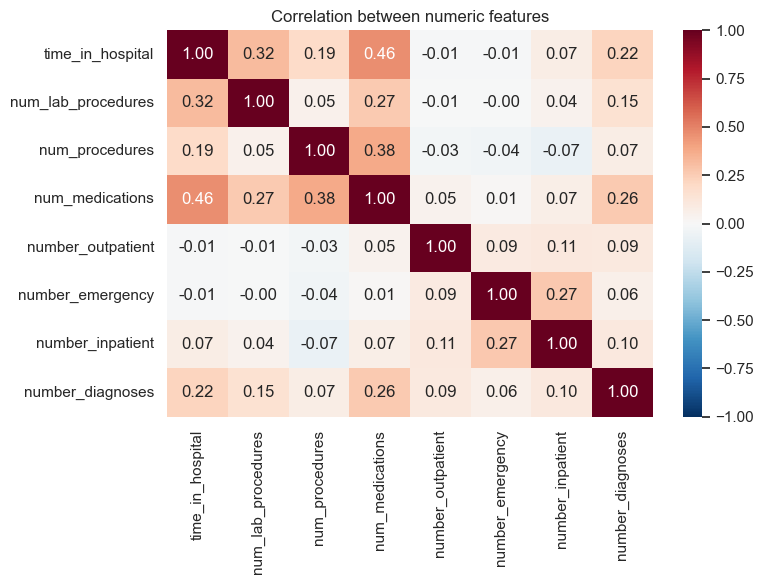


Strongest pairs:
time_in_hospital    num_medications       0.46
num_procedures      num_medications       0.38
time_in_hospital    num_lab_procedures    0.32
number_emergency    number_inpatient      0.27
num_lab_procedures  num_medications       0.27


In [37]:
corr = df[NUMERIC].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

high = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack().sort_values(ascending=False))
print("\nStrongest pairs:")
print(high.head(5).round(2).to_string())

---
## 10. Subgroup base rates


In [38]:
df["under_20"] = df["age"].isin(["[0-10)", "[10-20)"])

for label, grp in [("Age band", "age"), ("Race", "race"), ("Gender", "gender")]:
    g = df.groupby(grp, dropna=False)["target"].agg(n="size", rate="mean")
    g["rate_pct"] = (g["rate"] * 100).round(1)
    print(f"\n--- {label} ---")
    print(g[["n", "rate_pct"]].to_string())

u = df.groupby("under_20")["target"].agg(n="size", rate="mean")
print(f"\nUnder-20 subgroup: n={u.loc[True, 'n']:,}, "
      f"rate={u.loc[True, 'rate']:.1%} "
      f"(cohort {df['target'].mean():.1%})")


--- Age band ---
              n  rate_pct
age                      
[0-10)      160       1.9
[10-20)     689       5.8
[20-30)    1649      14.3
[30-40)    3764      11.3
[40-50)    9605      10.7
[50-60)   17060       9.8
[60-70)   22047      11.3
[70-80)   25324      12.0
[80-90)   16430      12.6
[90-100)   2588      11.9

--- Race ---
                     n  rate_pct
race                            
AfricanAmerican  18771      11.4
Asian              628      10.4
Caucasian        74197      11.5
Hispanic          2017      10.5
Other             1471       9.8
NaN               2232       8.4

--- Gender ---
            n  rate_pct
gender                 
Female  53444      11.5
Male    45872      11.3

Under-20 subgroup: n=849, rate=5.1% (cohort 11.4%)


In [39]:
# Subgroup base rates with confidence intervals, since several groups are small
# enough that the point estimate alone would overstate what I know.

from statsmodels.stats.proportion import proportion_confint

for col in ["age", "race", "gender"]:
    print(f"\n--- {col} ---")
    g = df.groupby(col, dropna=False)["target"].agg(n="size", k="sum")
    for idx, row in g.iterrows():
        lo, hi = proportion_confint(row["k"], row["n"], method="wilson")
        print(f"{str(idx):<18} n={row['n']:>6,}  {row['k']/row['n']:>5.1%}  "
              f"[{lo:.1%} – {hi:.1%}]")


--- age ---
[0-10)             n=   160   1.9%  [0.6% – 5.4%]
[10-20)            n=   689   5.8%  [4.3% – 7.8%]
[20-30)            n= 1,649  14.3%  [12.7% – 16.1%]
[30-40)            n= 3,764  11.3%  [10.3% – 12.3%]
[40-50)            n= 9,605  10.7%  [10.0% – 11.3%]
[50-60)            n=17,060   9.8%  [9.3% – 10.2%]
[60-70)            n=22,047  11.3%  [10.9% – 11.7%]
[70-80)            n=25,324  12.0%  [11.7% – 12.5%]
[80-90)            n=16,430  12.6%  [12.1% – 13.1%]
[90-100)           n= 2,588  11.9%  [10.7% – 13.2%]

--- race ---
AfricanAmerican    n=18,771  11.4%  [11.0% – 11.9%]
Asian              n=   628  10.4%  [8.2% – 13.0%]
Caucasian          n=74,197  11.5%  [11.3% – 11.7%]
Hispanic           n= 2,017  10.5%  [9.2% – 11.9%]
Other              n= 1,471   9.8%  [8.4% – 11.4%]
nan                n= 2,232   8.4%  [7.3% – 9.6%]

--- gender ---
Female             n=53,444  11.5%  [11.2% – 11.7%]
Male               n=45,872  11.3%  [11.0% – 11.6%]


## Subgroup base rates

Notebook 01 committed to reporting model performance by subgroup in notebook 04.
These are the base rates those results have to be read against — there's no point
comparing performance across groups whose underlying risk already differs.

I've put confidence intervals on everything, because a few of these groups are
small enough that a point estimate on its own would claim more precision than I
have.

### Age

| Band | n | Rate | 95% CI |
|---|---|---|---|
| [0-10) | 160 | 1.9% | 0.6 – 5.4 |
| [10-20) | 689 | 5.8% | 4.3 – 7.8 |
| [20-30) | 1,649 | 14.3% | 12.7 – 16.1 |
| [30-40) | 3,764 | 11.3% | 10.3 – 12.3 |
| [40-50) | 9,605 | 10.7% | 10.0 – 11.3 |
| [50-60) | 17,060 | 9.8% | 9.3 – 10.2 |
| [60-70) | 22,047 | 11.3% | 10.9 – 11.7 |
| [70-80) | 25,324 | 12.0% | 11.7 – 12.5 |
| [80-90) | 16,430 | 12.6% | 12.1 – 13.1 |
| [90-100) | 2,588 | 11.9% | 10.7 – 13.2 |

Risk doesn't rise with age here. It's a U with a spike on the left.

The 20-30 band is the highest in the dataset — 14.3%, above the eighties — and the
interval makes clear that isn't noise. Its lower bound sits above the upper bound
of every other adult band.

Clinically I think that's right, and it's the group I'd worry about most on a real
ward. Twenty-somethings admitted as diabetic inpatients are overwhelmingly type 1,
and that's the age when control falls apart. They leave home, they lose the
paediatric team that had been holding things together, they start paying for their
own insulin, and they come back in DKA. It's a recurring failure of support rather
than a recurring failure of the pancreas.

Then it dips through the forties and fifties before climbing again into old age,
which is the more familiar frailty and comorbidity pattern.

Anything that assumes risk increases monotonically with age will be wrong at both
ends of this curve.

### The under-20 question

Notebook 01 said I'd report [0-10) and [10-20) together as a single under-20
subgroup. Having seen the numbers I want to be honest that this is a compromise
rather than a clean decision.

The two bands aren't the same population. 1.9% against 5.8%, and their intervals
barely touch — [0-10) tops out at 5.4% and [10-20) starts at 4.3%. Pooling them
means averaging two groups that genuinely differ.

But [0-10) alone is three events on 160 encounters, with an interval running from
0.6% to 5.4%. That's a nine-fold range. It can't carry a performance estimate on
its own, and reporting calibration for a group like that would be theatre.

So I'm keeping them combined at 849 encounters and 43 events, and stating the
caveat rather than hiding it. When notebook 04 reports on the under-20 group, that
number is a blend of a very low-risk paediatric band and a higher-risk adolescent
one, and it should be read as such.

### Race and gender

| Group | n | Rate | 95% CI |
|---|---|---|---|
| Caucasian | 74,197 | 11.5% | 11.3 – 11.7 |
| African American | 18,771 | 11.4% | 11.0 – 11.9 |
| Hispanic | 2,017 | 10.5% | 9.2 – 11.9 |
| Asian | 628 | 10.4% | 8.2 – 13.0 |
| Other | 1,471 | 9.8% | 8.4 – 11.4 |
| Not recorded | 2,232 | 8.4% | 7.3 – 9.6 |
| Female | 53,444 | 11.5% | 11.2 – 11.7 |
| Male | 45,872 | 11.3% | 11.0 – 11.6 |

There's no difference here, and the intervals are what let me say that rather than
just observe it.

Caucasian and African American patients are 94% of the cohort and their intervals
overlap almost completely. Female and male are indistinguishable. The smaller
groups look slightly lower on the point estimates, but every one of their
intervals contains the cohort rate of 11.4% — that apparent gradient disappears
once you account for how few patients are in them.

This matters for the fairness work in notebook 04, and it's a more specific
starting point than I expected to have. No racial or gender group in this cohort
has a base rate distinguishable from any other. So if the model performs
differently across these groups, that difference cannot be coming from them
carrying different underlying risk. It would have to be coming from other features
correlating with group membership — which is a much narrower thing to go looking
for.

The one exception is the not-recorded group at 8.4%, whose interval doesn't reach
the cohort rate. That's the only genuinely distinct group here, and I already know
why: those are hurried admissions in patients the hospital hasn't seen before,
with half the prior admission history of everyone else. It isn't about race at
all.

---
## 11. Save the analysis dataset


In [40]:
out_path = f"{DATA_DIR}/processed/cohort_eda.csv"
df.to_csv(out_path, index=False)
print(f"Saved: {len(df):,} encounters x {df.shape[1]} columns")
print(f"Added since notebook 01: diag_1_group, diag_2_group, diag_3_group, under_20")

Saved: 99,316 encounters x 43 columns
Added since notebook 01: diag_1_group, diag_2_group, diag_3_group, under_20


In [41]:
# Confirm exactly what this notebook added

print(f"Columns: {df.shape[1]}")
print(f"Rows: {len(df):,}")
print("\nAll columns:")
print(list(df.columns))

Columns: 43
Rows: 99,316

All columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'readmitted', 'target', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'under_20']


## Summary

**What the data looks like.** 99,316 encounters and 43 columns — the 39 that came
out of notebook 01, plus the three diagnosis group columns and the under-20 flag
added here. The numeric variables behave the way they should. Medication counts
and lab procedures both accumulate with length of stay, and when I pulled the
extreme cases they turned out to be diabetic patients admitted with myocardial
infarctions for a fortnight, which is high but entirely real. Two things aren't
clinically clean. Length of stay is capped at 14 days by whoever built this
dataset, which quietly removes the sickest and most complicated discharges before
I ever see them. And `number_diagnoses` piles 48% of the cohort onto exactly nine
codes, which is a billing form limit rather than a distribution of illness. The
categorical variables are heavily concentrated: `medical_specialty` has 73 levels
but the top five cover 83%, and 44 of those levels hold fewer than 100 patients
each. The diagnosis codes needed grouping, and I ended up with 15 clinical
categories rather than the 9 I started with — after finding that "Other" contained
coherent blocks that behaved nothing like each other, and that collapsing all
diabetes codes into one bucket was hiding a ten-point spread between complicated
and uncomplicated disease.

**What the missingness means.** Seven columns have gaps and they fall into three
different situations. `medical_specialty` and `payer_code` are missing at random
as far as the outcome is concerned — both sit within a percentage point of the
base rate — so they get an "unknown" category and nothing more is claimed about
them. `A1Cresult` is informatively missing in the way I predicted in notebook 01:
patients whose HbA1c was never ordered come back at 11.7% against 9.9% for those
who had one, which supports reading the blank as a marker of how closely the
diabetes was being managed, though the effect is modest and I've softened the
notebook 01 wording accordingly. `max_glu_serum` runs the opposite way, and that
makes sense once you separate a test ordered because someone is acutely unwell
from a test ordered because someone is thinking about long-term control. The three
largest differences turned out not to be about missingness at all. A blank
`diag_3` means the patient had fewer conditions to code, not that information was
lost — those patients come back at 6.4% because there was less wrong with them.
And a blank `race` field, which had no clinical explanation, turned out to mark
hurried admissions in patients new to the hospital, with half the prior admission
history of everyone else. Nothing gets imputed. Everything becomes an explicit
category, for three different reasons.

**What the leakage hunt found.** I ranked every feature by how much readmission
rate varied across its levels, then checked each one against a single question:
would this value exist at the moment of discharge? Every column is accounted for.
The prior utilisation counts were the main risk and they came back clean — they
rise and fall within a patient, which confirms a rolling twelve-month prior window
rather than anything forward-looking, and the dose-response is smooth rather than
suspiciously sharp. The drug columns looked concerning until I checked them
properly: acarbose showed the widest spread of any drug at 24.8 points, resting on
three patients, and would have placed second in the entire feature table if I'd
trusted the ranking. That's a flaw in how I built the check, not a finding. Once
tiny groups are filtered out, no drug exceeds 4.3 points, and the three that
survive are measuring acuity rather than pharmacology — insulin's readmission rate
is elevated whether the dose went up or down, which is not how a drug effect
looks. The decision I'm least comfortable with is keeping
`discharge_disposition_id`. It's genuinely known at discharge and it carries
information about post-discharge support that nothing else does, but it's a
billing code whose labels I've already caught being wrong twice, and part of its
predictive power is severity that other features capture more honestly. I'm
keeping it and running a with-and-without comparison in notebook 03 rather than
deciding on instinct. Underneath all of this, the same pattern kept recurring: six
times a variable turned out to be measuring how sick the patient was rather than
what its name suggested. That's the most important thing this notebook produced,
because it means any feature importance plot from this dataset will be misread by
default unless someone says so./test split, a logistic regression baseline, and
calibration.